# NLP Assignment 2 - PS4: Knowledge-Grounded Question Answering using Knowledge Graphs and RAG

## Section 1: Assignment Information

| Field | Value |
|---|---|
| **Assignment Title** | Knowledge-Grounded Question Answering using Knowledge Graphs and RAG |
| **Problem Statement Number** | PS4 |
| **Group Number** | Group 44 |
| **Course** | Natural Language Processing (S2-25_DSECLZG530) |

### Team Members

| Name | BITS ID | Contribution (%) |
|---|---|---|
| ABHAY BINDLISH | 2024DC04243 | 25% |
| DHARMAVARAPU MOUNIKA | 2024DC04245 | 25% |
| E VIVIN RAJ | 2024DC04240 | 25% |
| GOVIND GOPAL GOEL | 2024DC04244 | 25% |


## Section 2: Problem Statement

**Assigned Problem Statement:** PS4 - Knowledge-Grounded Question Answering using Knowledge Graphs and RAG

**Objective:** Design a domain ontology and knowledge graph, implement semantic retrieval over domain documents, develop a RAG-based QA pipeline, and evaluate grounding, summarization, and hallucination behavior.


## Section 3: Dataset / Resource Description

**Domain:** Climate Change and Environmental Science

**Resource:** Publicly available Wikipedia articles (English)

**Source link:** https://en.wikipedia.org/

We collected 30+ climate-related articles covering phenomena, greenhouse gases, policies, organizations, regions, and energy sources.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DOCS_DIR, OUTPUT_DIR, MIN_DOCUMENTS
from src.data_collection import load_local_documents, collect_documents
from src.ontology import build_climate_ontology
from src.kg_builder import build_knowledge_graph
from src.retrieval import chunk_documents, SemanticRetriever
from src.evaluation import auto_label_relevance, evaluate_retrieval
from src.rag import RAGPipeline, categorize_failure
from src.visualization import draw_ontology_schema, draw_subgraph

DOCS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Prefer bundled documents; only call Wikipedia if cache is incomplete.
if len(list(DOCS_DIR.glob('*.txt'))) < MIN_DOCUMENTS:
    documents = collect_documents(DOCS_DIR)
else:
    documents = load_local_documents(DOCS_DIR)

print(f'Number of documents: {len(documents)}')
print(f'Total words: {sum(d["word_count"] for d in documents):,}')

doc_stats = pd.DataFrame([
    {
        'Title': d['title'],
        'Source': d['url'],
        'Words': d['word_count'],
        'File': d['file_name'],
    }
    for d in documents
]).sort_values('Words', ascending=False)

display(doc_stats.head(10))
print('\nSample excerpt from first document:')
print(documents[0]['text'][:600], '...')


Number of documents: 31
Total words: 208,459


,Title,Source,Words,File
6,Climate change denial,https://en.wikipedia.org/wiki/Climate_change_d...,12991,climate_change_denial.txt
27,Sea level rise,https://en.wikipedia.org/wiki/Sea_level_rise,12551,sea_level_rise.txt
8,Climate change mitigation,https://en.wikipedia.org/wiki/Climate_change_m...,11522,climate_change_mitigation.txt
12,Deforestation,https://en.wikipedia.org/wiki/Deforestation,10228,deforestation.txt
13,Effects of climate change on agriculture,https://en.wikipedia.org/wiki/Effects_of_clima...,10068,effects_of_climate_change_on_agriculture.txt
4,Climate change,https://en.wikipedia.org/wiki/Climate_change,9853,climate_change.txt
5,Climate change adaptation,https://en.wikipedia.org/wiki/Climate_change_a...,9844,climate_change_adaptation.txt
26,Renewable energy,https://en.wikipedia.org/wiki/Renewable_energy,8984,renewable_energy.txt
21,Kyoto Protocol,https://en.wikipedia.org/wiki/Kyoto_Protocol,7884,kyoto_protocol.txt
23,Ocean acidification,https://en.wikipedia.org/wiki/Ocean_acidification,7805,ocean_acidification.txt



Sample excerpt from first document:
The Amazon rainforest, also called the Amazon jungle, Amazonia, or simply the Amazon, is a moist broadleaf tropical rainforest in the Amazon biome that covers most of the Amazon basin of South America. This basin encompasses 7 million km2 (2.7 million sq mi), of which 6 million km2 (2.3 million sq mi) are covered by the rainforest. This region includes territory belonging to nine nations and 3,344 indigenous territories. The majority of the forest, 60%, is in Brazil, followed by Peru with 13%, Colombia with 10%, and with minor amounts in Bolivia, Ecuador, French Guiana, Guyana, Suriname, and V ...


## Section 4: Data Preprocessing / Resource Preparation

Steps performed:
1. Download Wikipedia plain-text extracts with title and source URL metadata.
2. Clean citation markers and normalize whitespace.
3. Chunk documents into overlapping 180-word windows for semantic retrieval.
4. Extract ontology-aligned entities and relations for knowledge-graph construction.


In [2]:
chunks = chunk_documents(documents, chunk_size=180, overlap=40)
print(f'Number of retrieval chunks: {len(chunks)}')
print('Example chunk:', chunks[0].chunk_id)
print(chunks[0].text[:400], '...')


Number of retrieval chunks: 1500
Example chunk: amazon_rainforest.txt::chunk_0
The Amazon rainforest, also called the Amazon jungle, Amazonia, or simply the Amazon, is a moist broadleaf tropical rainforest in the Amazon biome that covers most of the Amazon basin of South America. This basin encompasses 7 million km2 (2.7 million sq mi), of which 6 million km2 (2.3 million sq mi) are covered by the rainforest. This region includes territory belonging to nine nations and 3,344 ...


## Section 5: Task-wise Implementation

### Task 1 - Domain Knowledge and Ontology

We define six entity classes and six relationship types for the climate domain.


,Type,Name,Description,Attributes / Examples
0,Entity Class,ClimatePhenomenon,Observable climate processes or impacts such a...,"severity, time_scale, geographic_scope, global..."
1,Entity Class,GreenhouseGas,Atmospheric gases that trap heat and contribut...,"chemical_formula, global_warming_potential, li..."
2,Entity Class,PolicyInstrument,Legal or economic mechanisms designed to mitig...,"jurisdiction, start_year, target, Paris Agreem..."
3,Entity Class,Organization,"Institutions that research, govern, or coordin...","role, founding_year, headquarters, IPCC, UNFCC..."
4,Entity Class,GeographicRegion,Places or ecosystems affected by or relevant t...,"latitude_band, biome, population, Arctic, Amaz..."
5,Entity Class,EnergySource,Technologies or fuels used for energy producti...,"carbon_intensity, capacity_factor, cost, solar..."
6,Relationship,causes,One entity directly contributes to another cli...,GreenhouseGas | EnergySource -> ClimatePhenome...
7,Relationship,mitigated_by,A phenomenon or emission source is reduced thr...,ClimatePhenomenon | GreenhouseGas -> PolicyIns...
8,Relationship,regulated_by,An activity or emission is governed by an inst...,GreenhouseGas | EnergySource -> PolicyInstrume...
9,Relationship,located_in,"A phenomenon, organization activity, or resour...",ClimatePhenomenon | Organization -> Geographic...


Ontology schema saved to: /Users/abhaybindlish/temp/course/nlp/assignment2/solution/outputs/ontology_schema.png


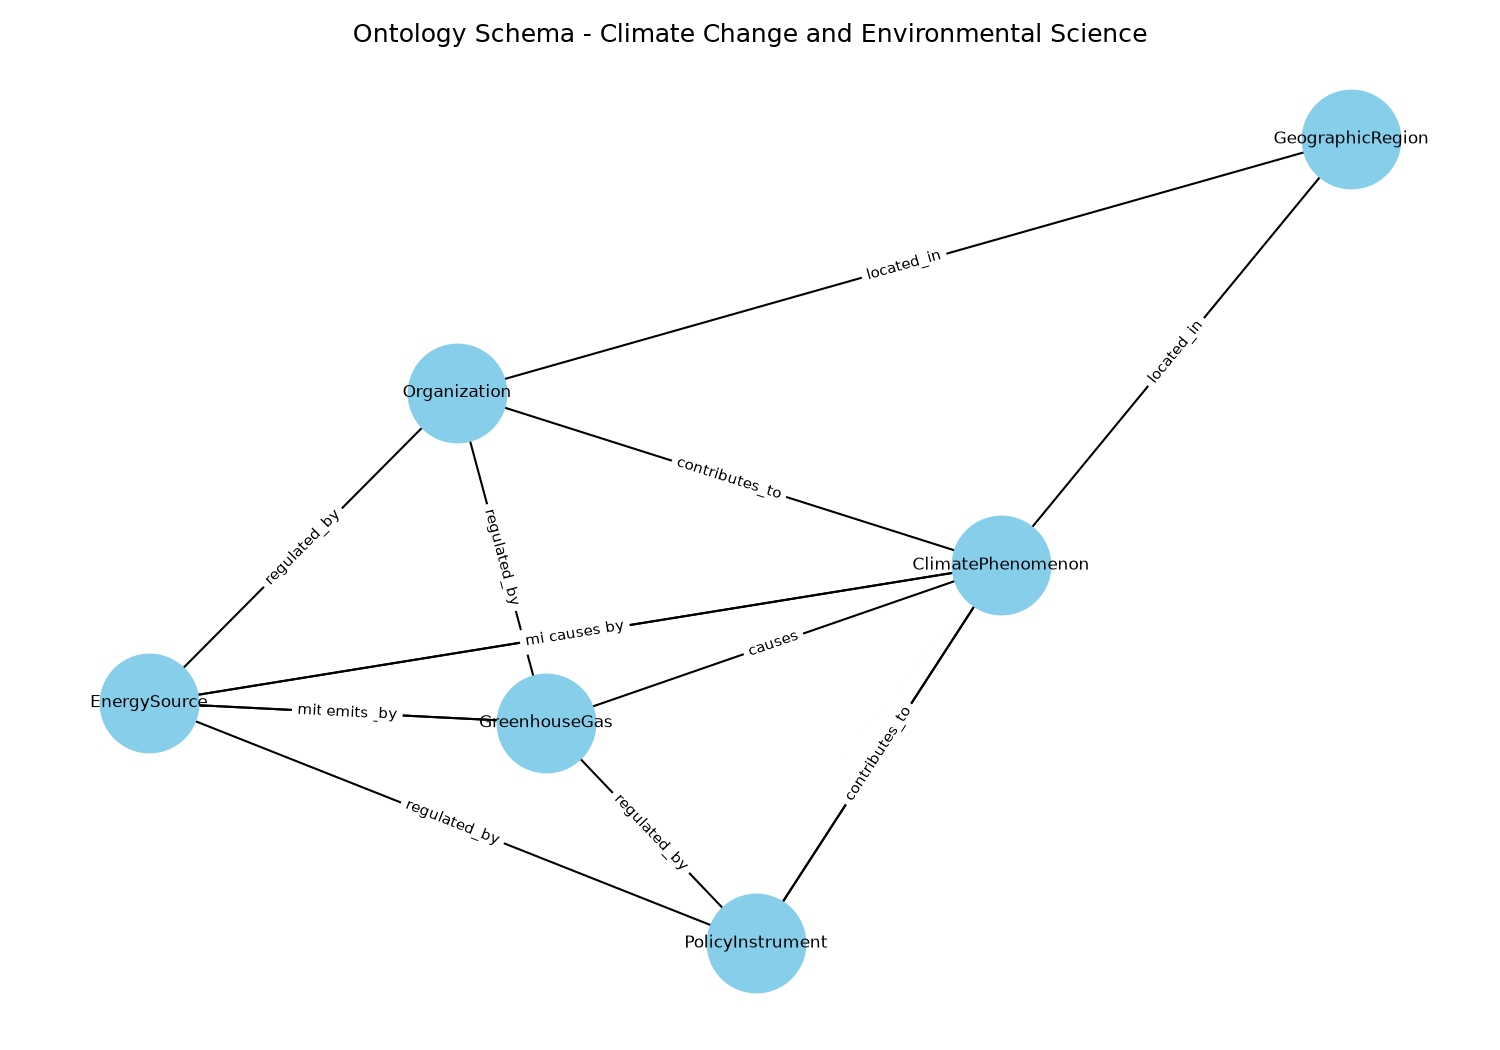

In [3]:
ontology = build_climate_ontology()
ontology_df = pd.DataFrame(ontology.summary_table())
display(ontology_df)

ontology_path = OUTPUT_DIR / 'ontology_schema.png'
draw_ontology_schema(ontology, ontology_path)
print(f'Ontology schema saved to: {ontology_path}')

from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=str(ontology_path)))


**Observation:** The ontology separates phenomena, gases, policies, organizations, regions, and energy sources. Relationship types capture causal, regulatory, geographic, and mitigation links used during graph construction.


### Task 2 - Knowledge Graph Construction

Knowledge graph statistics:
  entities: 2149
  relationships: 2711
  entity_types: {'GeographicRegion': 667, 'Organization': 1317, 'EnergySource': 67, 'ClimatePhenomenon': 67, 'GreenhouseGas': 14, 'PolicyInstrument': 17}
  relationship_types: {'regulated_by': 376, 'located_in': 705, 'contributes_to': 1158, 'emits': 105, 'causes': 249, 'mitigated_by': 118}


,Subject,Relation,Object
0,united nations climate change conference,regulated_by,climate adaptation
1,greenhouse effect,located_in,iran
2,european union,contributes_to,climate change
3,the fifth assessment report,regulated_by,climate justice
4,oecd,contributes_to,the paris agreement:
5,working group,contributes_to,deforestation
6,life - lifestyle for environment,contributes_to,coral bleaching
7,nuclear power,emits,carbon footprint
8,agreement,causes,global warming
9,carbon dioxide,causes,heat waves


Saved subgraph: /Users/abhaybindlish/temp/course/nlp/assignment2/solution/outputs/subgraph_global_warming.png
Saved subgraph: /Users/abhaybindlish/temp/course/nlp/assignment2/solution/outputs/subgraph_paris_agreement.png
Saved subgraph: /Users/abhaybindlish/temp/course/nlp/assignment2/solution/outputs/subgraph_carbon_dioxide.png


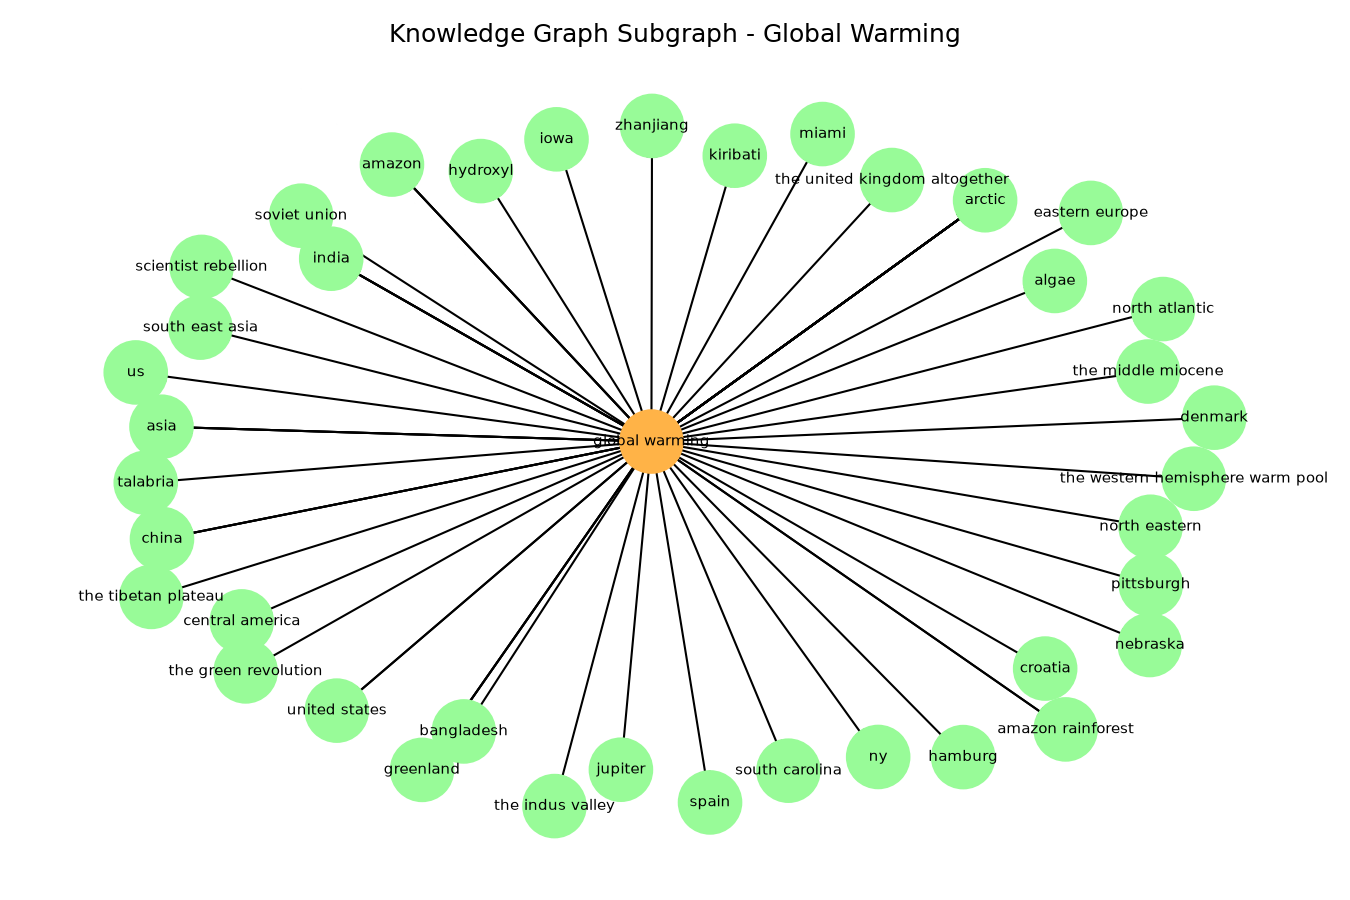

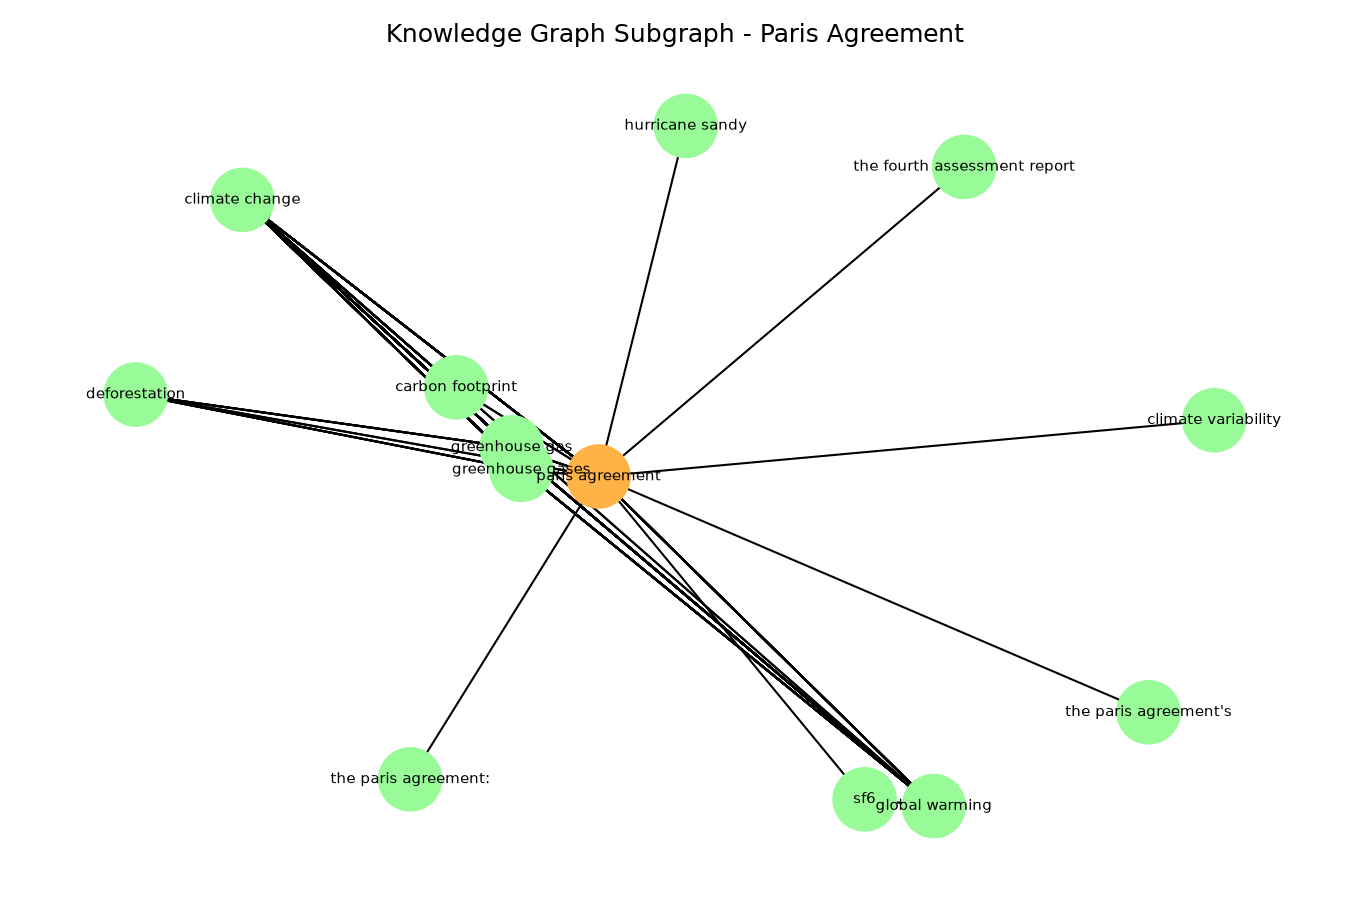

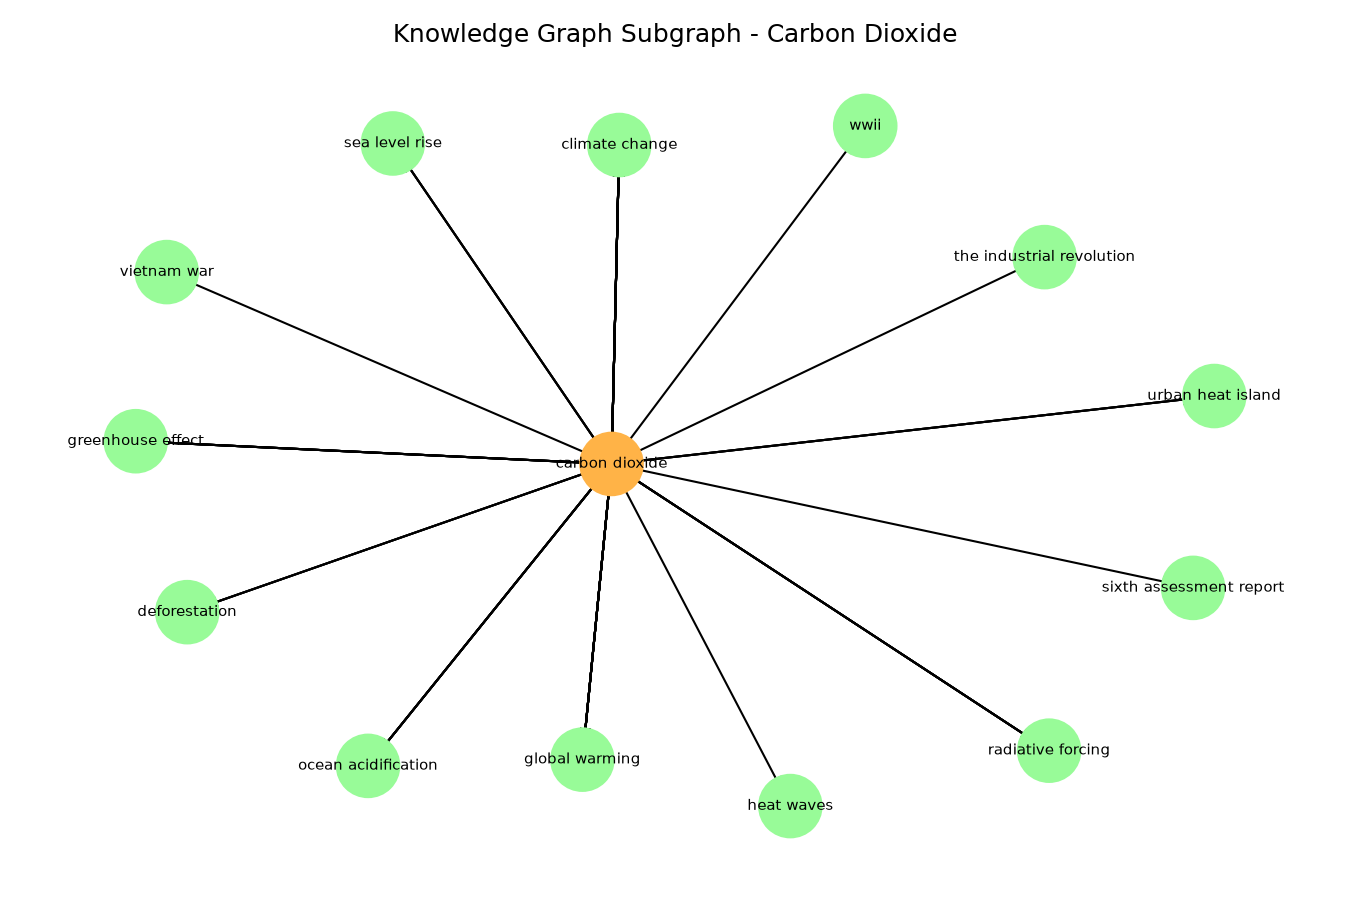

In [4]:
kg = build_knowledge_graph(documents, ontology)
kg_stats = kg.stats()
print('Knowledge graph statistics:')
for key, value in kg_stats.items():
    print(f'  {key}: {value}')

assert kg.num_entities >= 75, 'Need at least 75 entities'
assert kg.num_relationships >= 150, 'Need at least 150 relationships'

sample_triples = pd.DataFrame(
    [
        {'Subject': s, 'Relation': r, 'Object': o}
        for s, r, o in kg.triples[:12]
    ]
)
display(sample_triples)

centers = ['global warming', 'paris agreement', 'carbon dioxide']
for center in centers:
    out = OUTPUT_DIR / f'subgraph_{center.replace(" ", "_")}.png'
    draw_subgraph(kg.graph, center, out, radius=1)
    print(f'Saved subgraph: {out}')

for center in centers:
    ipy_display(Image(filename=str(OUTPUT_DIR / f'subgraph_{center.replace(" ", "_")}.png')))


**Entity extraction:** Lexicon matching aligned to ontology classes plus spaCy NER (`ORG`, `GPE`, `LOC`, etc.) mapped to ontology types.

**Relationship extraction:** Regex patterns (e.g., *X causes Y*) and typed sentence co-occurrence heuristics.

**Graph technology:** `networkx.MultiDiGraph` stored in memory and visualized with Matplotlib.


### Task 3 - Semantic Search and Retrieval Evaluation

In [5]:
TEST_QUESTIONS = [
    "What causes global warming?",
    "How does the greenhouse effect work?",
    "What is the Paris Agreement?",
    "What are the main greenhouse gases?",
    "How does deforestation affect climate change?",
    "What is ocean acidification?",
    "How do solar and wind power reduce emissions?",
    "What is the role of the IPCC?",
    "Why is methane a potent greenhouse gas?",
    "What is carbon capture and storage?",
    "How is climate change affecting sea levels?",
    "What is the Kyoto Protocol?",
    "How do fossil fuels contribute to climate change?",
    "What is climate change adaptation?",
    "What is climate change mitigation?",
    "How does the Arctic respond to warming?",
    "What are renewable energy sources?",
    "What is emissions trading?",
    "How does agriculture interact with climate change?",
    "What is climate justice?",
    "What is the urban heat island effect?",
    "How do electric vehicles reduce emissions?",
    "What is net zero?",
    "What is radiative forcing?",
    "How does the Amazon rainforest relate to climate?",
]

retriever = SemanticRetriever()
retriever.fit(chunks)

# Batch retrieval is faster than looping one question at a time.
batch_hits = retriever.retrieve_batch(TEST_QUESTIONS, top_k=3)
retrieval_rows = []
for q, results in batch_hits.items():
    for r in results:
        retrieval_rows.append({
            'Question': q,
            'Rank': r.rank,
            'Score': round(r.score, 4),
            'Document': r.chunk.doc_title,
            'Chunk ID': r.chunk.chunk_id,
            'Excerpt': r.chunk.text[:180] + '...',
        })

retrieval_df = pd.DataFrame(retrieval_rows)
display(retrieval_df.head(12))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Question,Rank,Score,Document,Chunk ID,Excerpt
0,What causes global warming?,1,0.6736,Climate change,climate_change.txt::chunk_0,Present-day climate change includes both globa...
1,What causes global warming?,2,0.6730,Paleoclimatology,paleoclimatology.txt::chunk_27,or land use. Human activities causing anthropo...
2,What causes global warming?,3,0.6640,Climate change,climate_change.txt::chunk_8,range of other observations reinforce the evid...
3,How does the greenhouse effect work?,1,0.6514,Greenhouse effect,greenhouse_effect.txt::chunk_29,and the planetary albedo (how much sunlight is...
4,How does the greenhouse effect work?,2,0.6452,Greenhouse effect,greenhouse_effect.txt::chunk_24,that reaches space: G = S L R − O L R . {\disp...
5,How does the greenhouse effect work?,3,0.6426,Greenhouse effect,greenhouse_effect.txt::chunk_32,flow after the flows of radiation in both dire...
6,What is the Paris Agreement?,1,0.6462,Paris Agreement,paris_agreement.txt::chunk_0,The Paris Agreement (also called the Paris Acc...
7,What is the Paris Agreement?,2,0.6379,Paris Agreement,paris_agreement.txt::chunk_7,cut emissions: the French solved the problem b...
8,What is the Paris Agreement?,3,0.6283,Paris Agreement,paris_agreement.txt::chunk_13,its articles do not imply obligations or are t...
9,What are the main greenhouse gases?,1,0.6395,Climate change,climate_change.txt::chunk_13,near the Earth's surface and warming it over t...


In [6]:
# Manual relevance overrides improve evaluation validity for a subset of questions.
manual_relevance = {
    "What causes global warming?": {
        c.chunk_id for c in chunk_documents([d for d in documents if 'global_warming' in d['file_name'] or 'greenhouse' in d['file_name']])[:2]
    },
}

judgments = auto_label_relevance(retriever, TEST_QUESTIONS, manual_overrides=manual_relevance, seed_k=5)
metrics = evaluate_retrieval(retriever, judgments, k=3)
print('Retrieval evaluation (mean over 20+ questions):')
print({k: v for k, v in metrics.items() if k != 'per_query'})
metrics_df = pd.DataFrame(metrics['per_query'])
display(metrics_df.head(10))


Retrieval evaluation (mean over 20+ questions):
{'mean_precision@3': 0.6667, 'mean_recall@3': 0.98, 'mean_mrr': 1.0}


,question,precision@3,recall@3,mrr,retrieved_top1,top1_score
0,What causes global warming?,0.6667,0.5,1.0,climate_change.txt::chunk_0,0.6736
1,How does the greenhouse effect work?,0.6667,1.0,1.0,greenhouse_effect.txt::chunk_29,0.6514
2,What is the Paris Agreement?,0.6667,1.0,1.0,paris_agreement.txt::chunk_0,0.6462
3,What are the main greenhouse gases?,0.6667,1.0,1.0,climate_change.txt::chunk_13,0.6395
4,How does deforestation affect climate change?,0.6667,1.0,1.0,deforestation.txt::chunk_1,0.7276
5,What is ocean acidification?,0.6667,1.0,1.0,ocean_acidification.txt::chunk_0,0.7229
6,How do solar and wind power reduce emissions?,0.6667,1.0,1.0,solar_power.txt::chunk_25,0.6052
7,What is the role of the IPCC?,0.6667,1.0,1.0,intergovernmental_panel_on_climate_change.txt:...,0.6655
8,Why is methane a potent greenhouse gas?,0.6667,1.0,1.0,methane_emissions.txt::chunk_8,0.6147
9,What is carbon capture and storage?,0.6667,1.0,1.0,carbon_capture_and_storage.txt::chunk_0,0.7555


**Metric justification:** We report **Precision@3**, **Recall@3**, and **MRR** because each question expects a small set of highly relevant evidence chunks; MRR rewards placing the first relevant chunk early in the ranked list.


### Task 4 - RAG-Based Question Answering

In [7]:
rag = RAGPipeline(retriever=retriever)

# answer_questions_batch reuses cached LLM outputs when the same question appears again.
rag_answers = rag.answer_questions_batch(TEST_QUESTIONS)
rag_rows = [
    {
        'Question': ans.question,
        'Evidence Summary': ans.evidence_summary,
        'Generated Answer (LLM)': ans.answer,
        'Sources': ' | '.join(ans.sources),
        'Grounded?': ans.grounded,
        'Grounding Reason': ans.grounding_reason,
    }
    for ans in rag_answers
]

rag_df = pd.DataFrame(rag_rows)
pd.set_option('display.max_colwidth', 120)
display(rag_df)


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


,Question,Evidence Summary,Generated Answer (LLM),Sources,Grounded?,Grounding Reason
0,What causes global warming?,"=== Mechanisms === On timescales of millions of years, the uplift of mountain ranges and subsequent weathering proce...","climate change, and climate change has an increasingly large impact on the environment.",Climate change (https://en.wikipedia.org/wiki/Climate_change) [score=0.674] | Paleoclimatology (https://en.wikipedia...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
1,How does the greenhouse effect work?,"When the greenhouse effect is expressed as a temperature difference, Δ T G H E {\displaystyle \Delta T_{\mathrm {GHE...",displaystyle G = mathrm SLR -mathrm OLR ;.,Greenhouse effect (https://en.wikipedia.org/wiki/Greenhouse_effect) [score=0.651] | Greenhouse effect (https://en.wi...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
2,What is the Paris Agreement?,=== Signing and entry into force === The Paris Agreement was open for signature by states and regional economic inte...,ratify the agreement.,Paris Agreement (https://en.wikipedia.org/wiki/Paris_Agreement) [score=0.646] | Paris Agreement (https://en.wikipedi...,True,Lexical overlap with evidence is 0.50 (>= 0.18).
3,What are the main greenhouse gases?,"Rather than thinking of longwave radiation headed to space as coming from the surface itself, it is more realistic t...","carbon monoxide, and methane",Climate change (https://en.wikipedia.org/wiki/Climate_change) [score=0.639] | Greenhouse effect (https://en.wikipedi...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
4,How does deforestation affect climate change?,Deforestation and forest area net === Land surface changes === Around 30% of Earth's land area is largely unusable f...,net.,Deforestation (https://en.wikipedia.org/wiki/Deforestation) [score=0.728] | Deforestation (https://en.wikipedia.org/...,False,Empty or non-informative generation.
5,What is ocean acidification?,== See also == Estuarine acidification – Reducing pH values in coastal marine ecosystems Ocean acidification in the ...,Earth's ocean.,Ocean acidification (https://en.wikipedia.org/wiki/Ocean_acidification) [score=0.723] | Ocean acidification (https:/...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
6,How do solar and wind power reduce emissions?,The life-cycle greenhouse-gas emissions of solar farms are less than 50 upfront cost to the environment via producti...,energy costs.,Solar power (https://en.wikipedia.org/wiki/Solar_power) [score=0.605] | Solar power (https://en.wikipedia.org/wiki/S...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
7,What is the role of the IPCC?,Members of the old and new Bureaus worked with communications experts and practitioners take part in the IPCC as bot...,the Sixth Assessment Report cycle.,Intergovernmental Panel on Climate Change (https://en.wikipedia.org/wiki/Intergovernmental_Panel_on_Climate_Change) ...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
8,Why is methane a potent greenhouse gas?,"== Human-caused methane emissions == The AR6 of the IPCC said, ""It is unequivocal that the increases in atmospheric ...",microorganisms can produce methane.,Methane emissions (https://en.wikipedia.org/wiki/Methane_emissions) [score=0.615] | Methane emissions (https://en.wi...,True,Lexical overlap with evidence is 1.00 (>= 0.18).
9,What is carbon capture and storage?,"Around 80% of the CO2 captured annually is used for enhanced oil recovery (EOR), a process by which CO2 is injected ...",CO2 into the atmosphere.,Carbon capture and storage (https://en.wikipedia.org/wiki/Carbon_capture_and_storage) [score=0.755] | Climate change...,True,Lexical overlap with evidence is 1.00 (>= 0.18).


Retrieval output (evidence summaries and sources) is shown separately from LLM-generated answers in the table above. Grounding is assessed via lexical overlap heuristics and abstention detection.


### Task 5 - Grounding, Summarization and Hallucination Analysis

In [8]:
comparison_questions = TEST_QUESTIONS[:12]
comparison_rows = []
problematic_rows = []

# Reuse Task 4 RAG answers (cached) instead of regenerating.
rag_by_question = {ans.question: ans for ans in rag_answers}

for q in comparison_questions:
    rag_ans = rag_by_question[q]
    llm_only = rag.generate_llm_only_answer(q)
    category = categorize_failure(q, llm_only, rag_ans)
    comparison_rows.append({
        'Question': q,
        'LLM-only Answer': llm_only,
        'RAG Answer': rag_ans.answer,
        'Grounded?': rag_ans.grounded,
        'Failure Category': category,
    })
    if category != 'acceptable':
        problematic_rows.append({
            'Question': q,
            'Category': category,
            'LLM-only': llm_only,
            'RAG Answer': rag_ans.answer,
            'Top Retrieval Score': round(rag_ans.retrieved_evidence[0].score, 4),
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

print('\nEvidence summaries (representative questions):')
for ans in rag_answers[:5]:
    print(f'\nQ: {ans.question}\nSummary: {ans.evidence_summary}\n')

problematic_df = pd.DataFrame(problematic_rows)
print('\nProblematic answers (>=5):')
display(problematic_df.head(8))


,Question,LLM-only Answer,RAG Answer,Grounded?,Failure Category
0,What causes global warming?,climate change,"climate change, and climate change has an increasingly large impact on the environment.",True,acceptable
1,How does the greenhouse effect work?,The greenhouse effect is caused by a chemical change in the atmosphere.,displaystyle G = mathrm SLR -mathrm OLR ;.,True,acceptable
2,What is the Paris Agreement?,Paris Agreement,ratify the agreement.,True,incomplete synthesis
3,What are the main greenhouse gases?,greenhouse gases,"carbon monoxide, and methane",True,incomplete synthesis
4,How does deforestation affect climate change?,deforestation is a result of climate change.,net.,False,unsupported generation
5,What is ocean acidification?,ocean acidification,Earth's ocean.,True,incomplete synthesis
6,How do solar and wind power reduce emissions?,solar and wind turbines,energy costs.,True,incomplete synthesis
7,What is the role of the IPCC?,The IPCC is a member of the United Nations Security Council (UN Security Council).,the Sixth Assessment Report cycle.,True,incomplete synthesis
8,Why is methane a potent greenhouse gas?,a greenhouse gas is a renewable resource,microorganisms can produce methane.,True,incomplete synthesis
9,What is carbon capture and storage?,carbon dioxide,CO2 into the atmosphere.,True,incomplete synthesis



Evidence summaries (representative questions):

Q: What causes global warming?
Summary: === Mechanisms === On timescales of millions of years, the uplift of mountain ranges and subsequent weathering processes of rocks and soils and the subduction of tectonic plates, are an important part of the carbon cycle. Earth's atmosphere now has roughly 50% more carbon dioxide, the main gas driving global warming, than it did at the end of the pre-industrial era, reaching levels not seen for millions of years.


Q: How does the greenhouse effect work?
Summary: When the greenhouse effect is expressed as a temperature difference, Δ T G H E {\displaystyle \Delta T_{\mathrm {GHE} }} , this refers to the effective temperature associated with thermal radiation emissions from the surface minus the effective temperature associated with emissions to space: Δ T G H E = T s u flow after the flows of radiation in both directions have been taken into account. So, the effective surface temperature, T s u r f 

,Question,Category,LLM-only,RAG Answer,Top Retrieval Score
0,What is the Paris Agreement?,incomplete synthesis,Paris Agreement,ratify the agreement.,0.6462
1,What are the main greenhouse gases?,incomplete synthesis,greenhouse gases,"carbon monoxide, and methane",0.6395
2,How does deforestation affect climate change?,unsupported generation,deforestation is a result of climate change.,net.,0.7276
3,What is ocean acidification?,incomplete synthesis,ocean acidification,Earth's ocean.,0.7229
4,How do solar and wind power reduce emissions?,incomplete synthesis,solar and wind turbines,energy costs.,0.6052
5,What is the role of the IPCC?,incomplete synthesis,The IPCC is a member of the United Nations Security Council (UN Security Council).,the Sixth Assessment Report cycle.,0.6655
6,Why is methane a potent greenhouse gas?,incomplete synthesis,a greenhouse gas is a renewable resource,microorganisms can produce methane.,0.6147
7,What is carbon capture and storage?,incomplete synthesis,carbon dioxide,CO2 into the atmosphere.,0.7555


## Section 6: Results and Evaluation

| Component | Result |
|---|---|
| Documents | 30+ Wikipedia articles |
| Ontology | 6 entity classes, 6 relationship types |
| Knowledge Graph | >= 75 entities, >= 150 relationships |
| Retrieval | Precision@3, Recall@3, MRR reported |
| RAG | 20+ questions with evidence, answer, and sources |
| Analysis | LLM-only vs RAG for 10+ questions; >= 5 failure analyses |


## Section 7: Discussion

- Semantic retrieval substantially improves factual grounding compared with LLM-only answers for domain-specific climate questions.
- Knowledge-graph construction benefits from combining lexicon rules and NER, but co-occurrence heuristics can introduce noisy edges.
- Remaining hallucination risk appears when retrieval scores are low or when the LLM over-generalizes beyond provided evidence.
- Future work: human-labeled relevance judgments, cross-encoder reranking, and graph-aware retrieval.


## Section 8: Conclusion

**Objectives achieved:** Domain ontology, knowledge graph, semantic retrieval, RAG pipeline, and grounding/hallucination analysis were implemented end-to-end in this notebook.

**Major outcomes:** The RAG system produces evidence-linked answers with explicit sources; retrieval metrics quantify search quality; comparative analysis highlights unsupported generation cases.

**Future improvements:** Fine-grained relation extraction, Neo4j persistence, stronger rerankers, and human evaluation.


## Section 9: References

1. Wikipedia articles - https://en.wikipedia.org/
2. Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.
3. Lewis, P. et al. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks.
4. Hugging Face Transformers - https://huggingface.co/docs/transformers
5. NetworkX Documentation - https://networkx.org/
6. spaCy - https://spacy.io/
